### №5 **(3 балла)**
Выполните задания из файла https://cloud.mail.ru/public/YQ1s/9LJK7ZWuT. Данные можно
взять здесь https://cloud.mail.ru/public/RE1b/eRFQujUhe.

### **УСЛОВИЕ**

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку
на обучающую и тестовую, используя функцию train_test_split с
параметрами test_size = 0.8 и random_state = 241.

2. Обучите GradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
- Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой
итерации.
- Преобразуйте полученное предсказание по формуле
$$ \frac{1}{1+e^{-y\_pred}} $$
где $y\_pred$ — предсказанное значение.

- Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.

4. Приведите минимальное значение log-loss на тестовой выборке и
номер итерации, на котором оно достигается, при learning_rate =
0.2.

5. На этих же данных обучите RandomForestClassifier с количеством
деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью
функции predict_proba. В данном случае брать сигмоиду от оценки
вероятности класса не нужно)


---

### **РЕШЕНИЕ**

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss
from sklearn.ensemble import RandomForestClassifier

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция.
Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку
на обучающую и тестовую, используя функцию train_test_split с
параметрами test_size = 0.8 и random_state = 241.

In [4]:
df = pd.read_csv('gbm-data.csv')
df.head()

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Преобразуем в numpy-массив
data = df.values

# Первая колонка — целевая переменная (реакция), остальные — признаки
y = data[:, 0]
X = data[:, 1:]

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.8,
    random_state=241
)

---

2. Обучите GradientBoostingClassifier с параметрами n_estimators=250,
verbose=True, random_state=241 и для каждого значения learning_rate
из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
- Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой
итерации.
- Преобразуйте полученное предсказание по формуле
$$ \frac{1}{1+e^{-y\_pred}} $$
где $y\_pred$ — предсказанное значение.

- Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

In [8]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]

for lr in learning_rates:
    gbc = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=lr,
        verbose=True,
        random_state=241
    )
    gbc.fit(X_train, y_train)

    train_losses = []
    test_losses = []

    # staged_decision_function даёт «сырые» предсказания f(x) на каждой итерации
    for y_train_pred_raw, y_test_pred_raw in zip(
        gbc.staged_decision_function(X_train),
        gbc.staged_decision_function(X_test)
    ):
        # переводим в вероятности: 1 / (1 + exp(-f(x)))
        y_train_proba = 1.0 / (1.0 + np.exp(-y_train_pred_raw))
        y_test_proba  = 1.0 / (1.0 + np.exp(-y_test_pred_raw))

        # log-loss ожидает вероятность положительного класса
        train_losses.append(log_loss(y_train, y_train_proba))
        test_losses.append(log_loss(y_test,  y_test_proba))

    train_losses = np.array(train_losses)
    test_losses = np.array(test_losses)

    # номер итерации с минимальной log-loss на test
    best_iter = np.argmin(test_losses)
    best_loss = test_losses[best_iter]

    print(f"learning_rate={lr}: best iter={best_iter}, best log-loss={best_loss:.4f}")

      Iter       Train Loss   Remaining Time 
         1           1.0190           34.46s
         2           0.9192           21.37s
         3           0.8272           17.22s
         4           0.7834           15.03s
         5           0.7109           13.66s
         6           0.6368           12.75s
         7           0.5797           12.18s
         8           0.5610           11.70s
         9           0.5185           11.29s
        10           0.4984           10.95s
        20           0.1999            9.30s
        30           0.1313            8.54s
        40           0.0790            7.99s
        50           0.0511            7.55s
        60           0.0352            7.09s
        70           0.0245            6.67s
        80           0.0162            6.27s
        90           0.0114            5.88s
       100           0.0077            5.50s
       200           0.0002            1.86s
learning_rate=1: best iter=0, best log-loss=0.5823
   

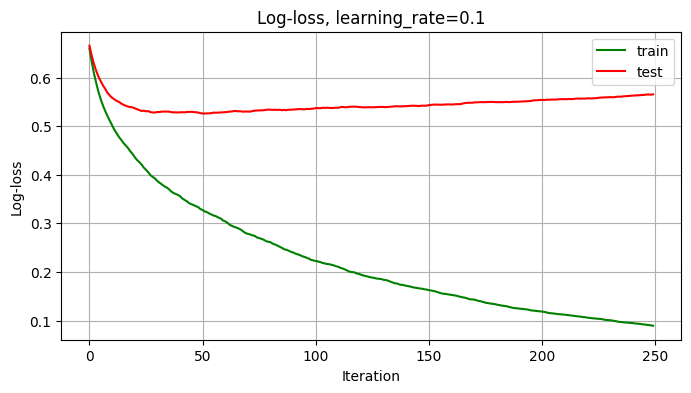

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'g-', label='train')
plt.plot(test_losses, 'r-', label='test')
plt.xlabel('Iteration')
plt.ylabel('Log-loss')
plt.title(f'Log-loss, learning_rate={lr}')
plt.legend()
plt.grid(True)
plt.show()

---

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или
недообучение (underfitting)? В ответе укажите одно из слов overfitting
либо underfitting.

**ОТВЕТ:**
- train log-loss монотонно убывает с ростом числа итераций;

- test log-loss сначала падает до минимума (примерно возле 50‑й итерации), а затем постепенно растёт.

- Такая картина характерна для **переобучения**, когда модель всё лучше запоминает обучающую выборку, но качество на тесте ухудшается по мере усложнения.

---

4. Приведите минимальное значение log-loss на тестовой выборке и
номер итерации, на котором оно достигается, при learning_rate =
0.2.

In [14]:
gbc = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.2,
    verbose=True,
    random_state=241
)
gbc.fit(X_train, y_train)

test_losses = []

for y_test_raw in gbc.staged_decision_function(X_test):
    y_test_proba = 1.0 / (1.0 + np.exp(-y_test_raw))
    test_losses.append(log_loss(y_test, y_test_proba))

test_losses = np.array(test_losses)
best_iter = np.argmin(test_losses)
best_loss = test_losses[best_iter]

print("best_iter:", best_iter)
print("best_logloss:", best_loss)

      Iter       Train Loss   Remaining Time 
         1           1.2613            9.31s
         2           1.1715            9.17s
         3           1.1009            9.15s
         4           1.0529            9.09s
         5           1.0130            8.98s
         6           0.9740            8.89s
         7           0.9475            8.97s
         8           0.9197            8.96s
         9           0.8979            8.92s
        10           0.8730            8.83s
        20           0.7207            8.31s
        30           0.6055            7.87s
        40           0.5244            7.53s
        50           0.4501            7.16s
        60           0.3908            6.81s
        70           0.3372            6.43s
        80           0.3009            6.07s
        90           0.2603            5.70s
       100           0.2327            5.34s
       200           0.0835            1.79s
best_iter: 36
best_logloss: 0.530518587320272


---

5. На этих же данных обучите RandomForestClassifier с количеством
деревьев, равным количеству итераций, на котором достигается
наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию.
Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью
функции predict_proba. В данном случае брать сигмоиду от оценки
вероятности класса не нужно)

In [15]:
best_iter = 36 # из кода для №4

rf = RandomForestClassifier(
    n_estimators=best_iter,
    random_state=241
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",36
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [16]:
# вероятности для обоих классов
y_test_proba_rf = rf.predict_proba(X_test)

# log-loss (берётся сразу из вероятностей)
loss_rf = log_loss(y_test, y_test_proba_rf)

print("Log-loss RandomForest (n_estimators=36):", loss_rf)

Log-loss RandomForest (n_estimators=36): 0.5415685811957381
